In [1]:
import io
import zipfile
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
state_url = "https://www.bls.gov/oes/special-requests/oesm25st.zip"
metro_url = "https://www.bls.gov/oes/special-requests/oesm25ma.zip"

headers = {
    "User-Agent": "Mozilla/5.0"
}

state_response = requests.get(
    state_url,
    headers=headers,
    verify=False
)

metro_response = requests.get(
    metro_url,
    headers=headers,
    verify=False
)

print("State request:", state_response.status_code)
print("Metro request:", metro_response.status_code)


c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bls.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bls.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


State request: 200
Metro request: 200


In [3]:
state_zip = zipfile.ZipFile(io.BytesIO(state_response.content))
metro_zip = zipfile.ZipFile(io.BytesIO(metro_response.content))

state_file = [
    f for f in state_zip.namelist()
    if f.endswith(".xlsx")
][0]

metro_file = [
    f for f in metro_zip.namelist()
    if "MSA_M2025" in f and f.endswith(".xlsx")
][0]

with state_zip.open(state_file) as file:
    state_df = pd.read_excel(file)

with metro_zip.open(metro_file) as file:
    metro_df = pd.read_excel(file)

print("State data shape:", state_df.shape)
print("Metro data shape:", metro_df.shape)


State data shape: (37408, 32)
Metro data shape: (150023, 32)


In [4]:
nc_metros = metro_df[
    metro_df["PRIM_STATE"] == "NC"
].copy()

markets = [
    "Charlotte-Concord-Gastonia, NC-SC",
    "Durham-Chapel Hill, NC",
    "Greensboro-High Point, NC",
    "Raleigh-Cary, NC"
]

selected_metros = nc_metros[
    nc_metros["AREA_TITLE"].isin(markets)
].copy()

occupations = [
    "15-1212",  # Information Security Analysts
    "27-1024",  # Graphic Designers
    "25-2021",  # Elementary School Teachers, Except Special Education
    "47-2111",  # Electricians
    "29-1292"   # Dental Hygienists
]

analysis_df = selected_metros[
    selected_metros["OCC_CODE"].isin(occupations)
].copy()

print("Filtered dataset shape:", analysis_df.shape)
print("\nRows per metro:")
print(analysis_df.groupby("AREA_TITLE").size())


Filtered dataset shape: (20, 32)

Rows per metro:
AREA_TITLE
Charlotte-Concord-Gastonia, NC-SC    5
Durham-Chapel Hill, NC               5
Greensboro-High Point, NC            5
Raleigh-Cary, NC                     5
dtype: int64


In [5]:
final_df = analysis_df[
    [
        "AREA_TITLE",
        "OCC_CODE",
        "OCC_TITLE",
        "TOT_EMP",
        "A_MEDIAN",
        "LOC_QUOTIENT"
    ]
].copy()

final_df = final_df.rename(columns={
    "AREA_TITLE": "Metro_Area",
    "OCC_CODE": "Occupation_Code",
    "OCC_TITLE": "Occupation",
    "TOT_EMP": "Employment",
    "A_MEDIAN": "Median_Annual_Wage",
    "LOC_QUOTIENT": "Location_Quotient"
})

numeric_columns = [
    "Employment",
    "Median_Annual_Wage",
    "Location_Quotient"
]

for column in numeric_columns:
    final_df[column] = pd.to_numeric(
        final_df[column],
        errors="coerce"
    )

print("Shape:", final_df.shape)
print("\nMissing values:")
print(final_df.isna().sum())
print("\nDuplicate rows:", final_df.duplicated().sum())
print("\nObservations per occupation:")
print(final_df.groupby("Occupation").size())


Shape: (20, 6)

Missing values:
Metro_Area            0
Occupation_Code       0
Occupation            0
Employment            0
Median_Annual_Wage    0
Location_Quotient     0
dtype: int64

Duplicate rows: 0

Observations per occupation:
Occupation
Dental Hygienists                                       4
Electricians                                            4
Elementary School Teachers, Except Special Education    4
Graphic Designers                                       4
Information Security Analysts                           4
dtype: int64


In [6]:
page_url = "https://www.bls.gov/emp/publications/ai-exposure-categories.htm"
file_url = "https://www.bls.gov/emp/ind-occ-matrix/ai-exposure-categories.xlsx"

session = requests.Session()

browser_headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/153.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9"
}

page_response = session.get(
    page_url,
    headers=browser_headers,
    verify=False
)

file_headers = browser_headers.copy()
file_headers["Referer"] = page_url
file_headers["Accept"] = (
    "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet,"
    "application/octet-stream,*/*"
)

ai_response = session.get(
    file_url,
    headers=file_headers,
    verify=False
)

print("Source page request:", page_response.status_code)
print("AI workbook request:", ai_response.status_code)


c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bls.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Source page request: 200
AI workbook request: 200


c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bls.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [7]:
ai_df = pd.read_excel(
    io.BytesIO(ai_response.content),
    sheet_name="AI Exposure Categories",
    header=1
)

ai_selected = ai_df[
    [
        "2025 National Employment Matrix code",
        "Relative AI exposure",
        "Employment, 2025",
        "Employment, 2035",
        "Employment change, numeric, 2025–35",
        "Employment change, percent, 2025–35"
    ]
].copy()

ai_selected = ai_selected.rename(columns={
    "2025 National Employment Matrix code": "Occupation_Code",
    "Relative AI exposure": "AI_Exposure",
    "Employment, 2025": "National_Employment_2025",
    "Employment, 2035": "Projected_Employment_2035",
    "Employment change, numeric, 2025–35": "Projected_Employment_Change",
    "Employment change, percent, 2025–35": "Projected_Employment_Change_Pct"
})

ai_selected = ai_selected[
    ai_selected["Occupation_Code"].isin(occupations)
].copy()

display(ai_selected)


,Occupation_Code,AI_Exposure,National_Employment_2025,Projected_Employment_2035,Projected_Employment_Change,Projected_Employment_Change_Pct
70,15-1212,Very high,192.9,233.4,40.6,21.0
238,25-2021,High,1419.3,1413.4,-5.8,-0.4
271,27-1024,Very high,253.1,248.8,-4.2,-1.7
347,29-1292,Low,225.3,243.2,17.9,8.0
582,47-2111,Moderate,821.0,896.9,75.9,9.2


In [8]:
final_df = final_df.merge(
    ai_selected,
    on="Occupation_Code",
    how="left"
)

print("Final dataset shape:", final_df.shape)

print("\nMissing merged AI/projection values:")
print(
    final_df[
        [
            "AI_Exposure",
            "Projected_Employment_2035",
            "Projected_Employment_Change_Pct"
        ]
    ].isna().sum()
)

display(final_df.head())


Final dataset shape: (20, 11)

Missing merged AI/projection values:
AI_Exposure                        0
Projected_Employment_2035          0
Projected_Employment_Change_Pct    0
dtype: int64


,Metro_Area,Occupation_Code,Occupation,Employment,Median_Annual_Wage,Location_Quotient,AI_Exposure,National_Employment_2025,Projected_Employment_2035,Projected_Employment_Change,Projected_Employment_Change_Pct
0,"Charlotte-Concord-Gastonia, NC-SC",15-1212,Information Security Analysts,2640,131440,1.58,Very high,192.9,233.4,40.6,21.0
1,"Charlotte-Concord-Gastonia, NC-SC",25-2021,"Elementary School Teachers, Except Special Edu...",10770,58680,0.89,High,1419.3,1413.4,-5.8,-0.4
2,"Charlotte-Concord-Gastonia, NC-SC",27-1024,Graphic Designers,1640,59810,0.95,Very high,253.1,248.8,-4.2,-1.7
3,"Charlotte-Concord-Gastonia, NC-SC",29-1292,Dental Hygienists,1910,98390,0.98,Low,225.3,243.2,17.9,8.0
4,"Charlotte-Concord-Gastonia, NC-SC",47-2111,Electricians,5250,59080,0.79,Moderate,821.0,896.9,75.9,9.2


In [9]:
final_df[
    [
        "Employment",
        "Median_Annual_Wage",
        "Location_Quotient"
    ]
].describe().round(2)


,Employment,Median_Annual_Wage,Location_Quotient
count,20.00,20.00,20.00
mean,2370.00,79770.00,1.07
std,2520.65,29454.16,0.52
min,240.00,51400.00,0.53
25%,762.50,58980.00,0.79
50%,1775.00,60935.00,0.92
75%,2602.50,99465.00,1.10
max,10770.00,143640.00,2.75


In [10]:
occupation_summary = (
    final_df
    .groupby(["Occupation", "AI_Exposure"])
    .agg(
        Avg_Employment=("Employment", "mean"),
        Avg_Median_Wage=("Median_Annual_Wage", "mean"),
        Avg_Location_Quotient=("Location_Quotient", "mean"),
        Projected_Growth_Pct=("Projected_Employment_Change_Pct", "first")
    )
    .round(2)
    .reset_index()
)

display(occupation_summary)


,Occupation,AI_Exposure,Avg_Employment,Avg_Median_Wage,Avg_Location_Quotient,Projected_Growth_Pct
0,Dental Hygienists,Low,967.5,95725.0,0.90,8.0
1,Electricians,Moderate,3035.0,58370.0,0.91,9.2
2,"Elementary School Teachers, Except Special Edu...",High,5405.0,57495.0,0.84,-0.4
3,Graphic Designers,Very high,880.0,60082.5,0.98,-1.7
4,Information Security Analysts,Very high,1562.5,127177.5,1.72,21.0


In [11]:
metro_summary = (
    final_df
    .groupby("Metro_Area")
    .agg(
        Total_Selected_Occupation_Employment=("Employment", "sum"),
        Avg_Median_Wage=("Median_Annual_Wage", "mean"),
        Avg_Location_Quotient=("Location_Quotient", "mean")
    )
    .round(2)
    .reset_index()
)

display(metro_summary)


,Metro_Area,Total_Selected_Occupation_Employment,Avg_Median_Wage,Avg_Location_Quotient
0,"Charlotte-Concord-Gastonia, NC-SC",22210,81480.0,1.04
1,"Durham-Chapel Hill, NC",5170,81066.0,1.02
2,"Greensboro-High Point, NC",5680,72312.0,0.84
3,"Raleigh-Cary, NC",14340,84222.0,1.38


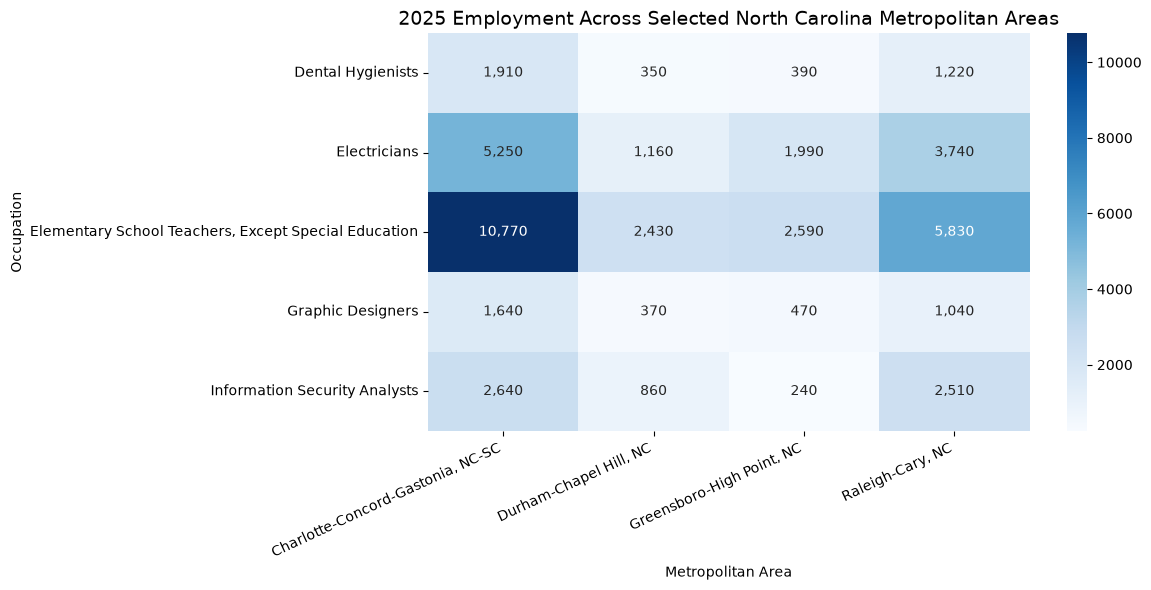

In [12]:
employment_heatmap = final_df.pivot(
    index="Occupation",
    columns="Metro_Area",
    values="Employment"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    employment_heatmap,
    annot=True,
    fmt=",.0f",
    cmap="Blues"
)

plt.title(
    "2025 Employment Across Selected North Carolina Metropolitan Areas",
    fontsize=14
)
plt.xlabel("Metropolitan Area")
plt.ylabel("Occupation")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


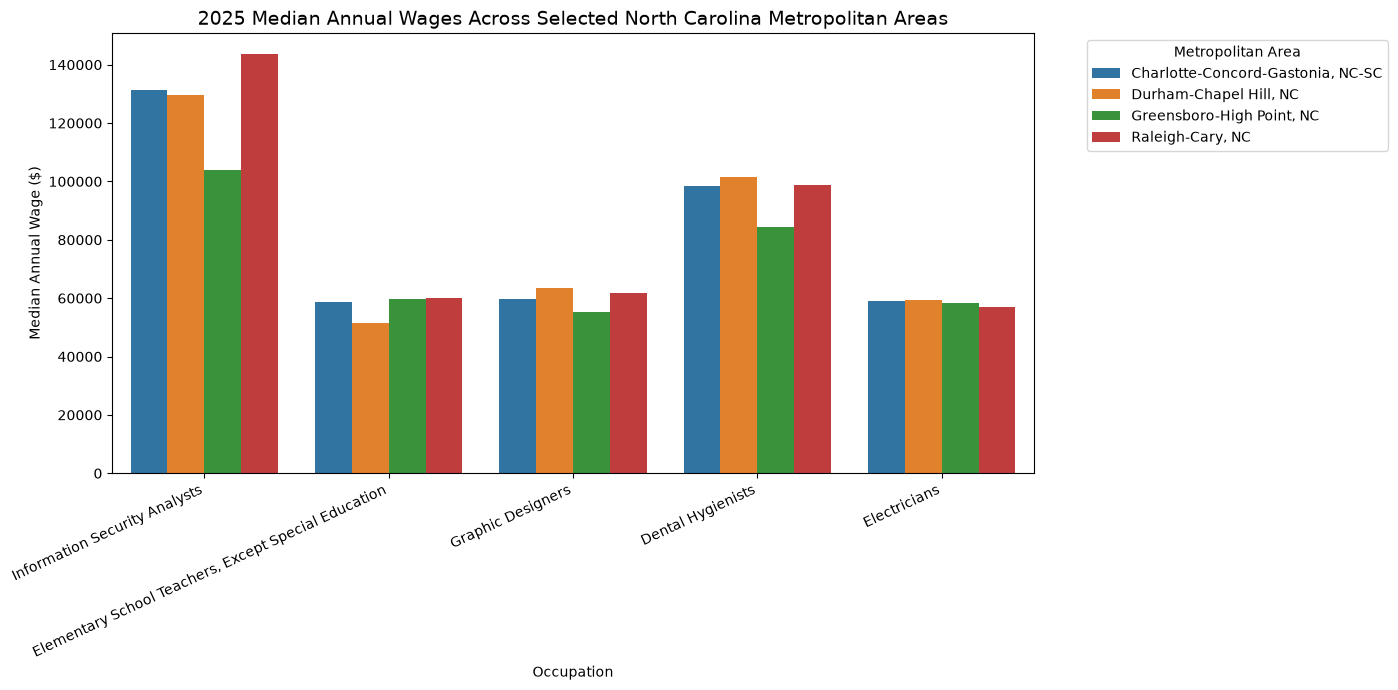

In [13]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=final_df,
    x="Occupation",
    y="Median_Annual_Wage",
    hue="Metro_Area"
)

plt.title(
    "2025 Median Annual Wages Across Selected North Carolina Metropolitan Areas",
    fontsize=14
)
plt.xlabel("Occupation")
plt.ylabel("Median Annual Wage ($)")
plt.xticks(rotation=25, ha="right")

plt.legend(
    title="Metropolitan Area",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


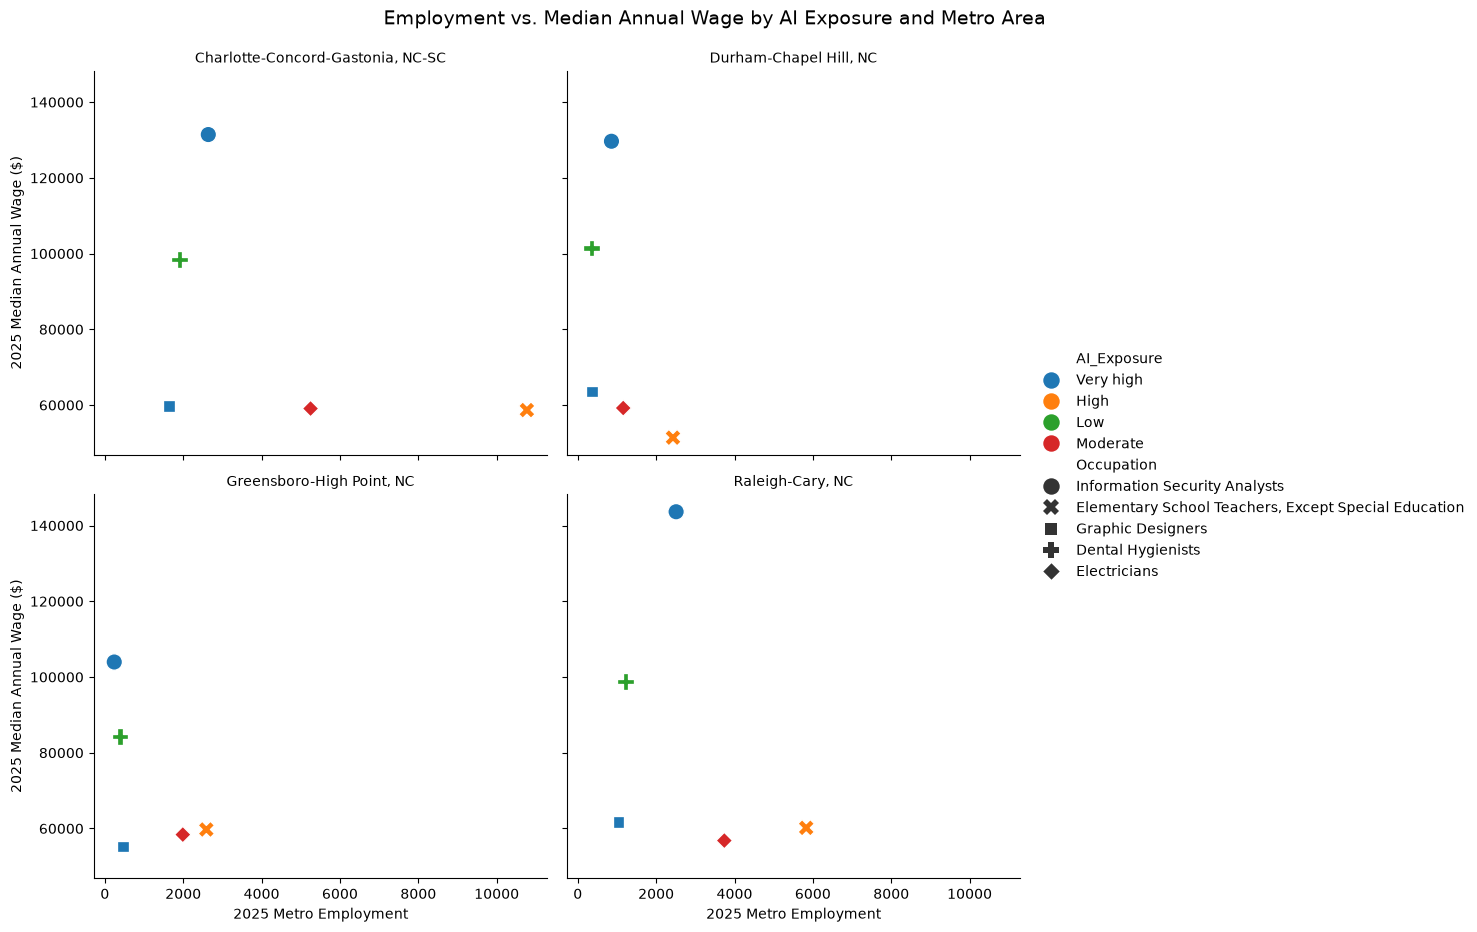

In [14]:
g = sns.relplot(
    data=final_df,
    x="Employment",
    y="Median_Annual_Wage",
    hue="AI_Exposure",
    style="Occupation",
    col="Metro_Area",
    col_wrap=2,
    s=140,
    height=4.5,
    aspect=1.2
)

g.set_axis_labels(
    "2025 Metro Employment",
    "2025 Median Annual Wage ($)"
)

g.set_titles("{col_name}")

g.fig.suptitle(
    "Employment vs. Median Annual Wage by AI Exposure and Metro Area",
    fontsize=14,
    y=1.03
)

plt.show()


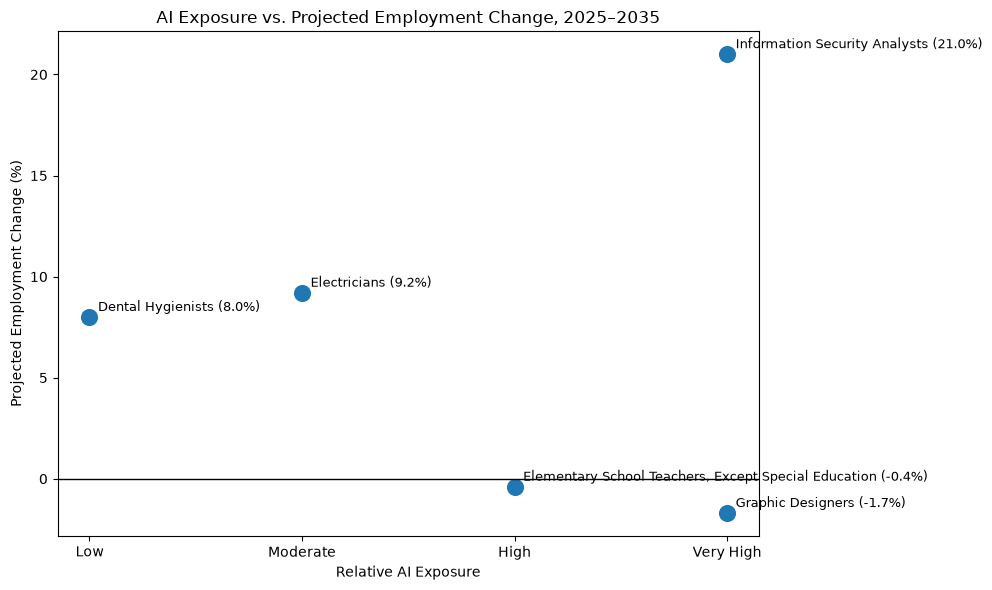

In [15]:
projection_df = final_df[
    [
        "Occupation",
        "AI_Exposure",
        "Projected_Employment_Change_Pct"
    ]
].drop_duplicates().copy()

exposure_order = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very high": 4
}

projection_df["AI_Exposure_Score"] = (
    projection_df["AI_Exposure"].map(exposure_order)
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=projection_df,
    x="AI_Exposure_Score",
    y="Projected_Employment_Change_Pct",
    s=180
)

for _, row in projection_df.iterrows():
    plt.text(
        row["AI_Exposure_Score"] + 0.04,
        row["Projected_Employment_Change_Pct"] + 0.3,
        f'{row["Occupation"]} ({row["Projected_Employment_Change_Pct"]:.1f}%)',
        fontsize=9
    )

plt.axhline(0, color="black", linewidth=1)

plt.xticks(
    [1, 2, 3, 4],
    ["Low", "Moderate", "High", "Very High"]
)

plt.title(
    "AI Exposure vs. Projected Employment Change, 2025–2035"
)
plt.xlabel("Relative AI Exposure")
plt.ylabel("Projected Employment Change (%)")

plt.tight_layout()
plt.show()
